In [50]:
# # 1. Gỡ cài đặt các thư viện cũ
# !pip uninstall numpy pandas prophet cmdstanpy -y

# # 2. Cài đặt đúng phiên bản (theo project gốc)
# !pip install numpy==1.26.4
# !pip install pandas==2.2.2
# !pip install lightgbm==4.3.0 optuna==3.6.1 scikit-learn==1.5.1
# !pip install matplotlib==3.6.0 seaborn==0.13.2 shap==0.44.1
#!pip install streamlit==1.35.0 joblib==1.4.2 pyarrow==20.0.0
!pip install cmdstanpy
!pip install prophet
!pip install lightgbm
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 27.2 MB/s eta 0:00:00


In [51]:
import numpy as np
import pandas as pd
import prophet
import joblib
import os
import sys
import torch

if torch.cuda.is_available():
    print(f"GPU activated: {torch.cuda.get_device_name(0)}")
else:
    print(" still CPU")

print("NumPy version:", np.__version__)      # Phải là 1.26.4
print("Pandas version:", pd.__version__)     # Phải là 2.2.2
print("Prophet version:", prophet.__version__) # Phải là 1.1.4

GPU activated: NVIDIA A100-SXM4-40GB
NumPy version: 2.0.2
Pandas version: 2.2.2
Prophet version: 1.3.0


In [52]:

# Thêm trực tiếp thư mục gốc của project vào sys.path
project_root = '/content/Walmart_sales_forecasting'
if project_root not in sys.path:
    sys.path.append(project_root)

print("Đã thêm đường dẫn:", project_root)

Đã thêm đường dẫn: /content/Walmart_sales_forecasting


In [53]:
import pandas as pd
import numpy as np
import torch
import prophet
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from src.metrics import weighted_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import joblib


In [54]:
%cd /content/Walmart_sales_forecasting
data_dir = 'data/processed/feature_engineering.feather'
df_feature = pd.read_feather(data_dir)
df_feature

/content/Walmart_sales_forecasting


,Store,Dept,Date,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,mean_sales_last_6_week,max_sales_last_6_week,min_sales_last_6_week,std_sales_last_6_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
6,1,1,2010-03-19,22136.64,151315,54.58,2.720,0.00,0.00,0.0,...,30360.018333,63593.12,7612.03,26384.953473,20940.430630,15246.700822,1242589.35,17258.185417,846686.47,18815.254889
149,1,2,2010-03-19,43615.49,151315,54.58,2.720,0.00,0.00,0.0,...,32780.786667,63593.12,7612.03,24477.831239,21538.535315,20414.155206,1242589.35,17258.185417,1742919.72,38731.549333
292,1,3,2010-03-19,9001.37,151315,54.58,2.720,0.00,0.00,0.0,...,29451.181667,61326.35,7612.03,20480.695326,32577.012657,37815.156301,1242589.35,17258.185417,371295.10,8251.002222
435,1,4,2010-03-19,34118.11,151315,54.58,2.720,0.00,0.00,0.0,...,20730.351667,43615.49,7612.03,14443.999382,20789.191329,16204.816575,1242589.35,17258.185417,1064848.12,23663.291556
578,1,5,2010-03-19,22632.57,151315,54.58,2.720,0.00,0.00,0.0,...,25148.031667,43615.49,9001.37,13661.565950,27453.650664,29639.786644,1242589.35,17258.185417,1063601.82,24734.926047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421012,45,93,2012-10-26,2487.80,118221,58.85,3.882,4018.91,58.08,100.0,...,17814.415000,54608.75,717.82,20287.128190,35354.118359,45312.322469,760281.43,11347.484030,1049693.34,24992.698571
421146,45,94,2012-10-26,5203.31,118221,58.85,3.882,4018.91,58.08,100.0,...,18109.411667,54608.75,1689.10,19999.636394,18920.959180,13193.930617,760281.43,11347.484030,1291378.41,29349.509318
421289,45,95,2012-10-26,56017.47,118221,58.85,3.882,4018.91,58.08,100.0,...,18695.113333,54608.75,2487.80,19466.945450,12062.134590,7200.965154,760281.43,11347.484030,1709432.51,37987.389111
421434,45,97,2012-10-26,6817.48,118221,58.85,3.882,4018.91,58.08,100.0,...,26666.748333,56017.47,2487.80,23647.747335,34039.802295,43813.343789,760281.43,11347.484030,596563.70,13558.265909


In [55]:
df_feature.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401996 entries, 6 to 421569
Data columns (total 46 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Store                   401996 non-null  int64         
 1   Dept                    401996 non-null  int64         
 2   Date                    401996 non-null  datetime64[ns]
 3   Weekly_Sales            401996 non-null  float64       
 4   Size                    401996 non-null  int64         
 5   Temperature             401996 non-null  float64       
 6   Fuel_Price              401996 non-null  float64       
 7   MarkDown1               401996 non-null  float64       
 8   MarkDown2               401996 non-null  float64       
 9   MarkDown3               401996 non-null  float64       
 10  MarkDown4               401996 non-null  float64       
 11  MarkDown5               401996 non-null  float64       
 12  CPI                     401996 non-

# **Build Prophet**

In [56]:
test = df_feature[df_feature['is_test']]
train = df_feature[~df_feature['is_test']]

prophet_data = df_feature.groupby(['Date', 'store_dept']).agg(
    {
        'Weekly_Sales' : 'sum',
        'Size' : 'first',
        'Type_B': 'first',         
        'Type_C': 'first',
        'IsHoliday_True' : 'first',
        'Temperature': 'first',
        'Fuel_Price' : 'first',
        "total_markdown": "first",   
        "avg_markdown": "first",      
        "max_markdown": "first",
        'lags_2' : 'first',
        'lags_4' : 'first',
        'lags_6' : 'first',
        'mean_sales_last_2_week' : 'first',
        'mean_sales_last_4_week' : 'first',
        'mean_sales_last_6_week' : 'first',
    }
).reset_index()

# Giả sử IsHoliday_True là 0 hoặc 1, total_markdown là một số
prophet_data['holiday_markdown'] = prophet_data['IsHoliday_True'] * prophet_data['total_markdown']

prophet_data

,Date,store_dept,Weekly_Sales,Size,Type_B,Type_C,IsHoliday_True,Temperature,Fuel_Price,total_markdown,avg_markdown,max_markdown,lags_2,lags_4,lags_6,mean_sales_last_2_week,mean_sales_last_4_week,mean_sales_last_6_week,holiday_markdown
0,2010-03-19,store_10_dept_1,38252.33,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,36572.44,49748.33,40212.84,2922.880,22868.6550,15501.406667,0.0
1,2010-03-19,store_10_dept_10,49479.06,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,49892.15,51199.72,48027.87,38420.625,35960.9575,43116.726667,0.0
2,2010-03-19,store_10_dept_11,30518.98,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,31934.99,33224.65,36705.57,59354.140,45381.1600,43213.585000,0.0
3,2010-03-19,store_10_dept_12,11762.04,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,11033.07,11032.90,10365.86,39999.020,39209.8225,37306.978333,0.0
4,2010-03-19,store_10_dept_13,65575.03,126512,True,False,False,61.46,3.054,0.00,0.000,0.00,70279.43,68060.96,74020.63,21140.510,40247.3250,37300.943333,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401991,2012-10-26,store_9_dept_91,914.84,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,698.84,998.95,1043.68,7728.250,6653.1025,6973.853333,0.0
401992,2012-10-26,store_9_dept_92,18310.28,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,20285.74,18333.69,18600.46,2005.805,4241.2575,5020.003333,0.0
401993,2012-10-26,store_9_dept_94,233.02,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,3.88,10.62,116.12,9612.560,8670.4050,7639.588333,0.0
401994,2012-10-26,store_9_dept_95,32382.05,125833,True,False,False,69.52,3.506,2189.61,437.922,1666.38,32072.80,33119.87,34591.81,9271.650,5638.7275,5918.055000,0.0


In [57]:
#handle missing case
regressor_cols = ['Type_B', 'Type_C', 'IsHoliday_True', 'Temperature', 'Fuel_Price', 'total_markdown']
prophet_data[regressor_cols] = prophet_data[regressor_cols].fillna(0)

In [58]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [59]:
def build_prophet_model(prophet_data,  test_data, checkpoint_dir="/content/drive/MyDrive/Walmart_checkpoints"):
    
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    min_test_time = test_data['Date'].min()
    max_test_time = test_data['Date'].max()
    
    prophet_model = {}
    prophet_predictions = {}
    prophet_metrics = pd.DataFrame(columns=['combo', 'mae', 'rmse', 'wape'])
    all_real = []
    all_predict = [] 
    
    scale_cols = ['Size', 'Temperature', 'Fuel_Price', 'total_markdown', 
                'lags_2', 'lags_4', 'lags_6',
                'mean_sales_last_2_week', 'mean_sales_last_4_week', 'mean_sales_last_6_week',
                'holiday_markdown']
    
    for combination in prophet_data['store_dept'].unique():
        print(f'Build prophet model for {combination}')
        
        model_path = os.path.join(checkpoint_dir,f"{combination}_model.pkl")
        forecast_path = os.path.join(checkpoint_dir,f"{combination}_forecast.csv")
        scaler_path = os.path.join(checkpoint_dir, f"{combination}_scaler.pkl")
        
        if os.path.exists(model_path) and os.path.exists(forecast_path):
            print(f"Load existing {combination}")
            model = joblib.load(model_path)
            forecast = pd.read_csv(forecast_path, parse_dates=['ds'])
            scaler = joblib.load(scaler_path)
            prophet_model[combination] = model
            prophet_predictions[combination] = forecast
            
            # recalc metrics
            mae = mean_absolute_error(forecast['y'], forecast['yhat'])
            rmse = np.sqrt(mean_squared_error(forecast['y'], forecast['yhat']))
            wape = weighted_absolute_percentage_error(forecast['y'], forecast['yhat'])
            prophet_metrics.loc[len(prophet_metrics)] = [combination, mae, rmse, wape]
            all_real.extend(forecast['y'])
            all_predict.extend(forecast['yhat'])
            continue
        
        combo = prophet_data[prophet_data['store_dept'] == combination].copy()
        combo = combo.rename(columns={'Date':'ds', 'Weekly_Sales' : 'y'}) #prophet require ds and y
        
        combo_train = combo[combo['ds'] < min_test_time]
        combo_test = combo[(combo['ds'] >= min_test_time) & (combo['ds'] <= max_test_time)]
        if combo_train.empty or combo_test.empty:
            print(f'Skip {combination} due to lack of data')
            continue
        
        # standardize value for model to learn
        available_cols = [col for col in scale_cols if col in combo_train.columns] 
        scaler = StandardScaler()
        if available_cols:
            scaler.fit(combo_train[available_cols])
            combo_train.loc[:, available_cols] = scaler.transform(combo_train[available_cols])
            combo_test.loc[:, available_cols] = scaler.transform(combo_test[available_cols])
        else:
            scaler = None
        
        # mulitplicative is not suitable for low sales due to being sensitive to changes
        if combo_train['y'].mean() < 50:
            model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True, seasonality_mode='additive', changepoint_prior_scale=0.2, holidays_prior_scale=15.0)
        else:
            model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True, seasonality_mode='multiplicative', changepoint_prior_scale=0.2, holidays_prior_scale=15.0)    
        
        #add regressor to learn
        regressors = ['Type_B', 'Type_C', 'IsHoliday_True'] + available_cols    
        for reg in regressors:
            if reg in combo_train.columns:
                model.add_regressor(reg)
        
        try:
            model.fit(combo_train)
        except Exception as e:
            print(f'Fail to train {combination} : {e}')
            continue
        
        # test
        future = combo_test[['ds'] + regressors]
        forecast = model.predict(future)
        
        forecast = forecast[['ds', 'yhat', 'yhat_upper', 'yhat_lower']].merge(combo_test[['ds', 'y']], on=['ds'])
        
        #save checkpoint
        joblib.dump(model, model_path)
        forecast.to_csv(forecast_path, index=False)
        if scaler is not None:
                    joblib.dump(scaler, scaler_path)
        print(f"Saved checkpoint for {combination}")
        
        prophet_model[combination] = model
        prophet_predictions[combination] = forecast
        
        # evaluate
        mae = mean_absolute_error(forecast['y'], forecast['yhat'])
        rmse = np.sqrt(mean_squared_error(forecast['y'], forecast['yhat']))
        
        wampe = weighted_absolute_percentage_error(forecast['y'], forecast['yhat']).item()
        
        prophet_metrics.loc[len(prophet_metrics)] = [combination, mae, rmse, wampe]
        
        #overall evaluation
        all_real.extend(forecast['y'])
        all_predict.extend(forecast['yhat'])
        
    
    mean_mae = np.mean(prophet_metrics['mae'])
    mean_rmse = np.mean(prophet_metrics['rmse'])
    ovr_wampe = weighted_absolute_percentage_error(all_real, all_predict)
    
    return prophet_model, prophet_predictions, (mean_mae, mean_rmse, ovr_wampe)


prophet_model, prophet_predictions, (mean_mae, mean_rmse, ovr_wampe) = build_prophet_model(prophet_data, test)
    
        
    

Build prophet model for  store_10_dept_1
Load existing  store_10_dept_1
Build prophet model for  store_10_dept_10
Load existing  store_10_dept_10
Build prophet model for  store_10_dept_11
Load existing  store_10_dept_11
Build prophet model for  store_10_dept_12
Load existing  store_10_dept_12
Build prophet model for  store_10_dept_13
Load existing  store_10_dept_13
Build prophet model for  store_10_dept_14
Load existing  store_10_dept_14
Build prophet model for  store_10_dept_16
Load existing  store_10_dept_16
Build prophet model for  store_10_dept_17
Load existing  store_10_dept_17
Build prophet model for  store_10_dept_18
Load existing  store_10_dept_18
Build prophet model for  store_10_dept_19
Load existing  store_10_dept_19
Build prophet model for  store_10_dept_2
Load existing  store_10_dept_2
Build prophet model for  store_10_dept_20
Load existing  store_10_dept_20
Build prophet model for  store_10_dept_21
Load existing  store_10_dept_21
Build prophet model for  store_10_dept_22


In [60]:
print(
    f"Prophet Model Results:\nMAE: {mean_mae:.2f} | RMSE: {mean_rmse:.2f} | WAPE: {ovr_wampe:.2f}"
)

Prophet Model Results:
MAE: 2673.80 | RMSE: 3243.38 | WAPE: 0.20


In [61]:
%cd /content/drive/MyDrive/Walmart_checkpoints
!ls


/content/drive/MyDrive/Walmart_checkpoints
' store_10_dept_10_forecast.csv'  ' store_2_dept_3_scaler.pkl'
' store_10_dept_10_model.pkl'	  ' store_2_dept_40_forecast.csv'
' store_10_dept_10_scaler.pkl'	  ' store_2_dept_40_model.pkl'
' store_10_dept_11_forecast.csv'  ' store_2_dept_40_scaler.pkl'
' store_10_dept_11_model.pkl'	  ' store_2_dept_41_forecast.csv'
' store_10_dept_11_scaler.pkl'	  ' store_2_dept_41_model.pkl'
' store_10_dept_12_forecast.csv'  ' store_2_dept_41_scaler.pkl'
' store_10_dept_12_model.pkl'	  ' store_2_dept_42_forecast.csv'
' store_10_dept_12_scaler.pkl'	  ' store_2_dept_42_model.pkl'
' store_10_dept_13_forecast.csv'  ' store_2_dept_42_scaler.pkl'
' store_10_dept_13_model.pkl'	  ' store_2_dept_44_forecast.csv'
' store_10_dept_13_scaler.pkl'	  ' store_2_dept_44_model.pkl'
' store_10_dept_14_forecast.csv'  ' store_2_dept_44_scaler.pkl'
' store_10_dept_14_model.pkl'	  ' store_2_dept_45_forecast.csv'
' store_10_dept_14_scaler.pkl'	  ' store_2_dept_45_model.pkl'
' store_

In [62]:
# Gộp tất cả dự báo thành một DataFrame
all_forecasts = pd.concat(prophet_predictions.values(), ignore_index=True)
print(all_forecasts.head())

          ds          yhat    yhat_upper    yhat_lower         y
0 2012-08-10  27786.872699  36931.432422  18604.955491  26320.29
1 2012-08-17  26425.677967  36120.610898  16107.849851  26752.40
2 2012-08-24  24946.320669  34626.744699  14595.631638  26804.84
3 2012-08-31  26208.567837  35253.520451  16001.099566  26083.28
4 2012-09-07  27726.515056  38329.760393  17396.368027  29426.33


In [63]:
import importlib
import src.plots
importlib.reload(src.plots)
from src.plots import visualize_pred, plot_prophet_comparison

df_prophet_pred = visualize_pred(prophet_predictions)
print(df_prophet_pred)

              ds          yhat    yhat_upper    yhat_lower         y  \
0     2012-08-10  27786.872699  36931.432422  18604.955491  26320.29   
1     2012-08-17  26425.677967  36120.610898  16107.849851  26752.40   
2     2012-08-24  24946.320669  34626.744699  14595.631638  26804.84   
3     2012-08-31  26208.567837  35253.520451  16001.099566  26083.28   
4     2012-09-07  27726.515056  38329.760393  17396.368027  29426.33   
...          ...           ...           ...           ...       ...   
35504 2012-08-31     57.961151     57.961152     57.961151      5.00   
35505 2012-09-14    235.267711    235.267712    235.267710      5.00   
35506 2012-09-28    378.769453    378.769455    378.769451      3.75   
35507 2012-10-05    336.777552    336.777555    336.777550      3.75   
35508 2012-10-12    215.677153    215.677156    215.677150      4.00   

              store_dept  
0        store_10_dept_1  
1        store_10_dept_1  
2        store_10_dept_1  
3        store_10_dept_1  


In [64]:
df_prophet_pred.groupby('store_dept').count().reset_index()
df_prophet_pred

,ds,yhat,yhat_upper,yhat_lower,y,store_dept
0,2012-08-10,27786.872699,36931.432422,18604.955491,26320.29,store_10_dept_1
1,2012-08-17,26425.677967,36120.610898,16107.849851,26752.40,store_10_dept_1
2,2012-08-24,24946.320669,34626.744699,14595.631638,26804.84,store_10_dept_1
3,2012-08-31,26208.567837,35253.520451,16001.099566,26083.28,store_10_dept_1
4,2012-09-07,27726.515056,38329.760393,17396.368027,29426.33,store_10_dept_1
...,...,...,...,...,...,...
35504,2012-08-31,57.961151,57.961152,57.961151,5.00,store_36_dept_32
35505,2012-09-14,235.267711,235.267712,235.267710,5.00,store_36_dept_32
35506,2012-09-28,378.769453,378.769455,378.769451,3.75,store_36_dept_32
35507,2012-10-05,336.777552,336.777555,336.777550,3.75,store_36_dept_32


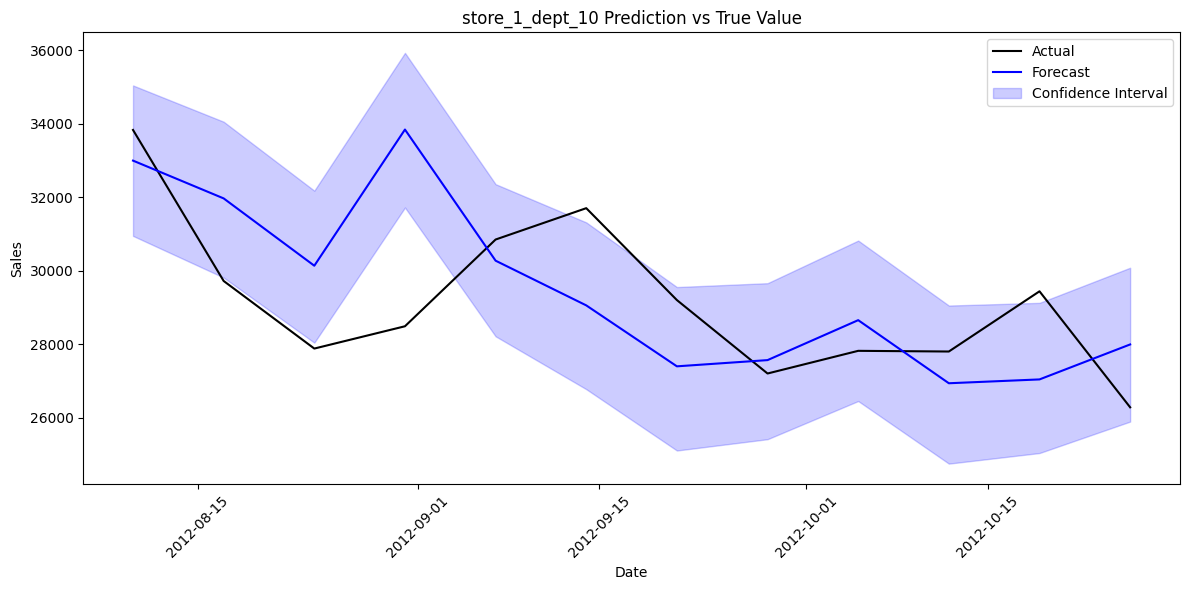

In [65]:
plot_prophet_comparison(df_prophet_pred, store_dept='store_1_dept_10')

# **Build LightGBM**

In [66]:
cols_to_drop = ['Date', 'store_dept', 'Weekly_Sales', 'Store', 'Dept', 'is_test']

X_train = df_feature[~df_feature['is_test']].drop(cols_to_drop, axis=1)
y_train = df_feature[~df_feature['is_test']]['Weekly_Sales']

X_test = df_feature[df_feature['is_test']].drop(cols_to_drop, axis=1)
y_test = df_feature[df_feature['is_test']]['Weekly_Sales']

X_train

,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,...,mean_sales_last_6_week,max_sales_last_6_week,min_sales_last_6_week,std_sales_last_6_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
6,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,211.215635,8.106,...,30360.018333,63593.12,7612.03,26384.953473,20940.430630,15246.700822,1242589.35,17258.185417,846686.47,18815.254889
149,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,211.215635,8.106,...,32780.786667,63593.12,7612.03,24477.831239,21538.535315,20414.155206,1242589.35,17258.185417,1742919.72,38731.549333
292,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,211.215635,8.106,...,29451.181667,61326.35,7612.03,20480.695326,32577.012657,37815.156301,1242589.35,17258.185417,371295.10,8251.002222
435,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,211.215635,8.106,...,20730.351667,43615.49,7612.03,14443.999382,20789.191329,16204.816575,1242589.35,17258.185417,1064848.12,23663.291556
578,151315,54.58,2.720,0.00,0.00,0.00,0.00,0.00,211.215635,8.106,...,25148.031667,43615.49,9001.37,13661.565950,27453.650664,29639.786644,1242589.35,17258.185417,1063601.82,24734.926047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421000,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,191.164090,8.684,...,16523.046667,47726.32,639.72,17509.146189,31767.816389,40144.232916,725729.51,10517.818986,1177581.75,28037.660714
421134,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,191.164090,8.684,...,16997.373333,47726.32,1656.99,17024.652421,17626.748194,12650.318229,725729.51,10517.818986,1332136.93,33303.423250
421277,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,191.164090,8.684,...,17467.578333,47726.32,3485.68,16548.530045,11052.484097,6521.244557,725729.51,10517.818986,1591798.85,35373.307778
421422,118221,76.58,3.654,24853.05,39.56,17.96,11142.69,2768.32,191.164090,8.684,...,24698.036667,52958.13,3485.68,21226.796885,32005.307049,41348.908639,725729.51,10517.818986,671580.72,15263.198182


In [85]:
import lightgbm as lgbm
from sklearn.model_selection import TimeSeriesSplit

def build_lightgbm(X_train, y_train, X_test, y_test):
    print('Building LightGBM model...')
    
    tss = TimeSeriesSplit(n_splits=5)
    
    #default param of lgbm
    param = {
        'objective' : 'regression',
        'metric' : 'rmse',
        'boosting_type' : 'gbdt',
        'num_leaves' : 31,
        'learning_rate' : 0.1,
        'feature_fraction' : 0.9,
        'n_estimators' : 100,
        'verbose' : -1, 
    }
    
    model = lgbm.LGBMRegressor(**param)
    cr_val = []
    
    for train_idx, val_idx in tss.split(X_train):
        X_train_cv = X_train.iloc[train_idx]
        y_train_cv =  y_train.iloc[train_idx]
        X_val_cv = X_train.iloc[val_idx]
        y_val_cv = y_train.iloc[val_idx]
        
        model.fit(
            X_train_cv,
            y_train_cv,
            eval_set=[(X_val_cv, y_val_cv)],
            # early_stopping_rounds=30,
            # verbose_eval=True,
        )
        
        pred = model.predict(X_val_cv)
        
        mae = mean_absolute_error(y_val_cv, pred)
        rmse = np.sqrt(mean_squared_error(y_val_cv, pred))
        wape = weighted_absolute_percentage_error(y_val_cv, pred)
        
        cr_val.append((mae, rmse, wape))
        
    avg_mae, avg_rmse, avg_wape = np.mean(cr_val, axis=0)
    print(f'Model Result:\n MAE : {avg_mae} | RMSE : {avg_rmse} | WAPE : {avg_wape}')
    
    #Test model
    print('Building Test Model..')
    test_model = lgbm.LGBMRegressor(**param)
    test_model.fit(X_train, y_train)
    test_pred = test_model.predict(X_test)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_wape = weighted_absolute_percentage_error(y_test, test_pred)
    df_test = df_feature[df_feature['is_test']].copy()
    df_test['y_true'] = y_test.values
    df_test['y_pred'] = test_pred
    df_test['error'] = np.abs(df_test['y_true'] - df_test['y_pred'])

    top_errors = df_test.sort_values('error', ascending=False).head(15)
    print(top_errors[['Date', 'Store', 'Dept', 'y_true', 'y_pred', 'error']])
    
    print(f'Test Model Result:\n MAE : {test_mae} | RMSE : {test_rmse} | WAPE : {test_wape}')
    
    return test_model, (test_mae, test_rmse, test_wape)
    
    
lgbm_model, (lgbm_mae, lgbm_rmse, lgbm_wape) = build_lightgbm(X_train, y_train, X_test, y_test)

Building LightGBM model...
Model Result:
 MAE : 2249.097707349988 | RMSE : 5448.024911692078 | WAPE : 0.1635389863672509
Building Test Model..
             Date  Store  Dept    y_true        y_pred         error
276183 2012-08-17     28    92  82794.34   8611.331308  74183.008692
369763 2012-09-14     39    90  82919.16  11064.556961  71854.603039
88658  2012-08-24     10     8  83540.73  11703.654108  71837.075892
9079   2012-09-28      1    90  80701.63  12589.736426  68111.893574
127455 2012-08-24     13    94  77292.63  12252.983222  65039.646778
217095 2012-08-24     23     2   7612.03  72215.824321  64603.794321
127456 2012-08-31     13    94  76190.91  11933.324799  64257.585201
338061 2012-10-26     35    72  78390.69  14729.498294  63661.191706
58529  2012-10-19      6    95  82656.99  19416.044203  63240.945797
313575 2012-10-05     32    95  82593.01  19939.201197  62653.808803
34786  2012-10-05      4    38   7612.03  70052.351759  62440.321759
133202 2012-09-28     14    3

In [74]:
X_test

,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,...,mean_sales_last_6_week,max_sales_last_6_week,min_sales_last_6_week,std_sales_last_6_week,emw_sales_0.5,emw_sales_0.75,sum_store_1_week,mean_store_1_week,sum_dept_1_week,mean_dept_1_week
131,151315,85.05,3.494,11436.22,245.00,6.85,6964.26,4836.22,221.958433,6.908,...,26442.326667,65566.19,20.00,24773.107041,11678.435286,4270.057245,1161428.40,16130.95000,645714.28,14349.206222
274,151315,85.05,3.494,11436.22,245.00,6.85,6964.26,4836.22,221.958433,6.908,...,18201.281667,38451.35,20.00,15728.449533,13899.177643,13157.454311,1161428.40,16130.95000,1720055.02,38223.444889
417,151315,85.05,3.494,11436.22,245.00,6.85,6964.26,4836.22,221.958433,6.908,...,24720.928333,46729.91,20.00,18350.129434,30314.543821,38336.796078,1161428.40,16130.95000,1197157.74,26603.505333
560,151315,85.05,3.494,11436.22,245.00,6.85,6964.26,4836.22,221.958433,6.908,...,23021.920000,46729.91,20.00,17264.402224,29285.921911,30777.174019,1161428.40,16130.95000,1250046.56,27778.812444
703,151315,85.05,3.494,11436.22,245.00,6.85,6964.26,4836.22,221.958433,6.908,...,23708.741667,46729.91,20.00,17962.462358,34814.875955,37952.166005,1161428.40,16130.95000,636480.17,14144.003778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421012,118221,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,...,17814.415000,54608.75,717.82,20287.128190,35354.118359,45312.322469,760281.43,11347.48403,1049693.34,24992.698571
421146,118221,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,...,18109.411667,54608.75,1689.10,19999.636394,18920.959180,13193.930617,760281.43,11347.48403,1291378.41,29349.509318
421289,118221,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,...,18695.113333,54608.75,2487.80,19466.945450,12062.134590,7200.965154,760281.43,11347.48403,1709432.51,37987.389111
421434,118221,58.85,3.882,4018.91,58.08,100.00,211.94,858.33,192.308899,8.667,...,26666.748333,56017.47,2487.80,23647.747335,34039.802295,43813.343789,760281.43,11347.48403,596563.70,13558.265909


In [ ]:
import numpy as np

# Giả sử final_pred là dự báo trên test, y_test là thực tế
errors = np.abs(y_test - final_pred)
print("Sai số lớn nhất:", np.max(errors))
print("Vị trí sai số lớn nhất:", np.argmax(errors))
print("10 sai số lớn nhất:", np.sort(errors)[-10:])

# **Finetune LightGBM**

In [71]:
import optuna
def optimizing_lgbm(X_train, y_train, X_test, y_test):
    
    print('Optimizing LightGBM with optuna..')
    
    def objective(trial):
        params = {
            "objective": "regression",
            "metric": "rmse",
            "boosting_type": "gbdt",
            "num_leaves": trial.suggest_int("num_leaves", 15, 50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.7, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.7, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
            "n_estimators": 1000,
            "verbose": -1,
        }
        
        model = lgbm.LGBMRegressor(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            callbacks=[lgbm.early_stopping(stopping_rounds=50)]
        )
        pred = model.predict(X_test)
       
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        return rmse
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=50)
    
    best_params = study.best_params
    # best param only return the param found, not the fixed one so we have to add fixed param to match
    best_params.update(
        {
            'objective' : 'regression',
            'metric' : 'rmse',
            'boosting_type' : 'gbdt',
            'verbose' : -1,
        }
    )
    
    print(f'Best params:\n')
    for key, value in best_params.items():
        print(f'{key} : {value}')
        
    final_model = lgbm.LGBMRegressor(**best_params)
    final_model.fit(X_train, y_train)
    final_pred = final_model.predict(X_test)
    final_mae = mean_absolute_error(y_test, final_pred)
    final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
    final_wape = weighted_absolute_percentage_error(y_test, final_pred)
    
    print(f'Optimized LightGBM Model:\n MAE : {final_mae} | RMSE : {final_rmse} | WAPE : {final_wape}')
    
    return final_model, (final_mae, final_rmse, final_wape)


opt_model, (opt_mae, opt_rmse, opt_wape) = optimizing_lgbm(X_train, y_train, X_test, y_test)
    
    
    
    
    

[I 2026-08-09 09:05:13,093] A new study created in memory with name: no-name-be3e5d0f-96b4-40c5-878d-605c04d953d6


Optimizing LightGBM with optuna..
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[892]	valid_0's rmse: 4400.17


[I 2026-08-09 09:05:23,246] Trial 0 finished with value: 4400.17193762443 and parameters: {'num_leaves': 34, 'learning_rate': 0.08818449758650695, 'feature_fraction': 0.8373163322692272, 'bagging_fraction': 0.9798328480948193, 'bagging_freq': 3, 'min_child_samples': 8}. Best is trial 0 with value: 4400.17193762443.


Training until validation scores don't improve for 50 rounds


[I 2026-08-09 09:05:31,064] Trial 1 finished with value: 4494.734225726091 and parameters: {'num_leaves': 16, 'learning_rate': 0.09132015016384254, 'feature_fraction': 0.8821559405242398, 'bagging_fraction': 0.8792117099861092, 'bagging_freq': 2, 'min_child_samples': 25}. Best is trial 0 with value: 4400.17193762443.


...

Early stopping, best iteration is:
[670]	valid_0's rmse: 4414.19
Training until validation scores don't improve for 50 rounds


[I 2026-08-09 09:12:57,968] Trial 48 finished with value: 4473.836429592393 and parameters: {'num_leaves': 36, 'learning_rate': 0.09470838382132685, 'feature_fraction': 0.7013847351783992, 'bagging_fraction': 0.9485166093218563, 'bagging_freq': 2, 'min_child_samples': 7}. Best is trial 26 with value: 4347.293728843824.


Early stopping, best iteration is:
[546]	valid_0's rmse: 4473.84
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[996]	valid_0's rmse: 4453.19


[I 2026-08-09 09:13:08,363] Trial 49 finished with value: 4453.192045118391 and parameters: {'num_leaves': 46, 'learning_rate': 0.029349563996044256, 'feature_fraction': 0.7422477533659456, 'bagging_fraction': 0.9781686534018514, 'bagging_freq': 1, 'min_child_samples': 10}. Best is trial 26 with value: 4347.293728843824.


Best params:

num_leaves : 48
learning_rate : 0.09199347585988366
feature_fraction : 0.7601767418332392
bagging_fraction : 0.963526631848584
bagging_freq : 1
min_child_samples : 21
objective : regression
metric : rmse
boosting_type : gbdt
verbose : -1
Optimized LightGBM Model:
 MAE : 1789.8842434670955 | RMSE : 4547.5088970768575 | WAPE : 0.13187308480962312
